# Enclave Inference — Gemma 3 — Benchmark Owner

| Actor | Email | Role |
|-------|-------|------|
| **Enclave** | `enclave@openmined.org` | Trusted execution environment |
| **Model owner** | `model_owner@openmined.org` | Owns the Gemma 3 model (weights + inference engine) |
| **Benchmark owner** | `benchmark_owner@openmined.org` | Owns the private benchmark **and submits the inference job** |

**The setting.** These clients connect to an [enclave](https://github.com/OpenMined/PySyft/tree/dev/packages/syft-enclave) — a sealed environment that runs code on data nobody can see. There are two data owners: the **model owner** (other notebook), who keeps the model private, and the **benchmark owner** (this notebook), who keeps the benchmark private. Both upload their assets into the enclave, and nothing runs on them unless **both owners approve the exact code** first.

We also submit the inference job — a data owner client can do both.

The model owner's inference code is private. So before the model runs on our benchmark, we approve a [syft-restrict](https://github.com/OpenMined/PySyft/tree/dev/packages/syft-restrict) job and get back a certificate proving the code only does allow-listed math and cannot leak our benchmark — our assurance for letting it run on our prompts.

## Setup

In [ ]:
!uv pip install -Uq "git+https://github.com/OpenMined/PySyft.git@enclave-mvp#subdirectory=packages/syft-enclave"

In [ ]:
import csv
import json
import random
import tempfile
from pathlib import Path


from syft_enclaves import login_do

In [ ]:
ENCLAVE_EMAIL     = "test.enclave@gmail.com"
MODEL_OWNER_EMAIL = "test.model.owner@gmail.com"

# The model owner publishes these on their mock model card; hardcoded here so the notebook is self-contained.
MODEL_SIZE  = "270m"
CKPT_SUBDIR = "gemma-3-270m-it"

print(f"  Enclave: {ENCLAVE_EMAIL}  |  Model owner: {MODEL_OWNER_EMAIL}  |  Model size: {MODEL_SIZE}")

## Step 0 — Log in as Benchmark Owner

We log in to the enclave. This client lets us upload data and approve jobs in the enclave.

In [ ]:
benchmark_owner = login_do(encryption=True)
print(f"  Benchmark owner : {benchmark_owner.email}")

In [ ]:
# # Optionally to clear state
# benchmark_owner._manager.delete_syftbox()
# benchmark_owner._manager.peer_manager.write_own_version()

### Launch the enclave

## Step 1 — Peer with the Enclave and the Model Owner

To make requests to the enclave, we first need to peer with it. We also peer with the model owner so we can browse their mock model card.

In [ ]:
benchmark_owner.add_peer(ENCLAVE_EMAIL)
benchmark_owner.add_peer(MODEL_OWNER_EMAIL)
print("  Peer requests sent to the enclave and the model owner")

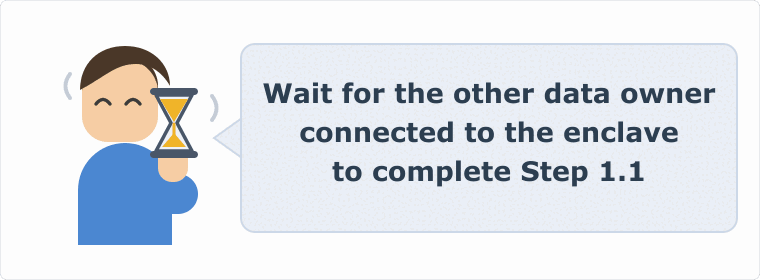


### Step 1.1 — Wait until the Model Owner approves

The Model Owner approves your request from their notebook. Re-run the cell below until they appear as an approved peer.

In [ ]:
benchmark_owner.peers

### Step 1.2 — Attest the enclave's identity

Here we validate the attestation report. It confirms the standard enclave properties — the hashes of the BIOS, operating system, system processes, and applications — and signs those hashes with a private key that only the enclave holds. It also confirms the exact PySyft version and configuration. This ties the approvals of both the model owner and the benchmark owner to the exact code, inputs, parameters, and output policy. PySyft handles all of this automatically. This signed hash could only be faked if the hardware provider and the model owner colluded.

In [ ]:
# Wait for enclave to accept peer request
benchmark_owner.attest_peer(ENCLAVE_EMAIL)

## Step 2 — Prepare the benchmark

We download a small pre-split sample of the [MLCommons AILuminate](https://github.com/mlcommons/ailuminate) demo prompt set — 5 rows as the public **mock** benchmark and 5 rows as the private benchmark. This is our private data. Uploading it into the enclave does not allow anything on its own — the benchmark is only used once we approve a job that runs against it.

> **Provenance.** Both CSVs are a deterministic 10-row sample (first prompt per hazard) of [`airr_official_1.0_demo_en_us_prompt_set_release.csv`](https://github.com/mlcommons/ailuminate/blob/main/airr_official_1.0_demo_en_us_prompt_set_release.csv), checked into this repo under `notebooks/enclave/gemma/data/`. The columns are **changed** relative to the MLCommons file to match the real AILuminate reserve prompt set: `release_prompt_id` is renamed to `prompt_uid`, `persona` and `prompt_hash` are dropped, and the order is `prompt_uid, hazard, locale, prompt_text`.

In [ ]:
DATA_URL = "https://raw.githubusercontent.com/OpenMined/PySyft/refs/heads/dev/notebooks/enclave/gemma/data"
MOCK_CSV = "safety_prompts_mock.csv"
PRIVATE_CSV = "safety_prompts.csv"

# Column names/order of the real AILuminate reserve prompt set (see provenance note above).
EXPECTED_COLUMNS = [
    "prompt_uid",
    "hazard",
    "locale",
    "prompt_text",
]


def read_prompt_csv(path: Path) -> list[dict]:
    """Read a prompt CSV and check it has exactly the expected columns."""
    with open(path, newline="") as f:
        reader = csv.DictReader(f)
        assert reader.fieldnames == EXPECTED_COLUMNS, reader.fieldnames
        return list(reader)

In [ ]:
!mkdir -p prompts/mock prompts/private
!curl -sfL "{DATA_URL}/{MOCK_CSV}" -o "prompts/mock/{MOCK_CSV}"
!curl -sfL "{DATA_URL}/{PRIVATE_CSV}" -o "prompts/private/{PRIVATE_CSV}"

prompt_mock = Path("prompts/mock") / MOCK_CSV
prompt_private = Path("prompts/private") / PRIVATE_CSV

mock_rows = read_prompt_csv(prompt_mock)
private_rows = read_prompt_csv(prompt_private)

print(f"Mock prompts   : {len(mock_rows)}")
print(f"Private prompts: {len(private_rows)}")

## Step 3 — Upload the benchmark

We upload the benchmark into the enclave. The public (mock) side is a few sample prompts; the private side is the full set, shared only with the enclave.

In [ ]:
benchmark_owner.create_dataset(
    name="safety_prompts",
    mock_path=prompt_mock,
    private_path=prompt_private,
    summary="MLCommons AILuminate safety evaluation prompts — bias, stereotyping, and safety boundary tests",
    users=[ENCLAVE_EMAIL],
)
benchmark_owner.share_private_dataset("safety_prompts", ENCLAVE_EMAIL)

print(f"  Benchmark owner uploaded 'safety_prompts' ({len(private_rows)} private prompts)")

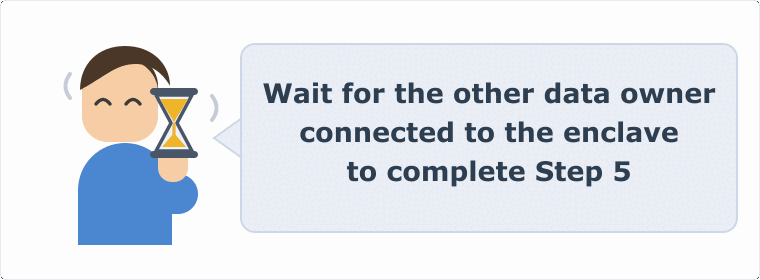


## Step 4 — Review the `syft-restrict` job

The model owner submits a [syft-restrict](https://github.com/OpenMined/PySyft/tree/dev/packages/syft-restrict) job on their inference code. We review it carefully. syft-restrict does two things:

1. It creates a readable copy of the code with the private regions hidden.
2. It analyses the code and makes sure the private code only uses non-dynamic Python that cannot leak our benchmark.

We approve because we are the party relying on this guarantee.

In [ ]:
RESTRICT_JOB_NAME = "restrict_engine_review"
restrict_job = next((j for j in benchmark_owner.jobs if j.name == RESTRICT_JOB_NAME), None)

if restrict_job is None:
    print(f" 🟠 Job '{RESTRICT_JOB_NAME}' not visible yet — the enclave is still distributing it. Wait a moment and re-run this cell.")
else:
    print(f"  Benchmark owner sees '{RESTRICT_JOB_NAME}'  status={restrict_job.status}")

In [ ]:
restrict_job

In [ ]:
benchmark_owner.approve_job(restrict_job)
print("  Benchmark owner approved")

### Step 4.1 — Read the certificate

Once both owners approve, the enclave runs the check and sends us the certificate plus an obfuscated copy of the code: signatures visible, bodies blanked. The certificate proves the syft-restrict guarantees hold. The architecture stays secret.

In [ ]:
restrict_job = next(j for j in benchmark_owner.jobs if j.name == RESTRICT_JOB_NAME)

if restrict_job.status != "done":
    print(f" 🟠 Job '{RESTRICT_JOB_NAME}' status={restrict_job.status} — wait until it is 'done', then re-run this cell.")
else:
    outputs = {p.name: p for p in restrict_job.output_paths}
    print(f"  Output files : {list(outputs)}")

    cert = json.loads(outputs["gemma_inference.certificate.json"].read_text())
    print(f"  calls checked : {cert['n_calls_checked']}")
    print(f"  policy id     : {cert['policy_id']}")
    print(f"  source sha256 : {cert['source_sha256']}")

## Step 5 — Submit the inference job

We browse the model owner's mock, then submit the job that runs the model on our benchmark. It loads
`gemma_inference.py` + weights from `gemma3_model` and our prompts from `safety_prompts` (the AILuminate CSV),
loops over each row, and writes `outputs/safety_eval_results.json` — including the `prompt_uid` for each
row. `dependencies` tells the enclave what to install at job runtime.

In [ ]:
benchmark_owner.datasets

In [ ]:
def create_code_file(code: str) -> str:
    tmp = Path(tempfile.mkdtemp()) / f"job-{random.randint(1, 1_000_000)}"
    tmp.mkdir(parents=True, exist_ok=True)
    p = tmp / "main.py"
    p.write_text(code)
    return str(p)


JOB_NAME = "safety_eval_job"
JOB_CODE = f'''
import csv
import json
import os

import syft_client as sc

# Resolve Model owner's private model dataset directory
model_files = sc.resolve_dataset_files_path(
    "gemma3_model", owner_email="{MODEL_OWNER_EMAIL}"
)
weights_dir = str(model_files[0].parent)

# Import the inference module from the model owner's private dataset
gemma = sc.load_dataset_code(
    "gemma3_model.gemma_inference", owner_email="{MODEL_OWNER_EMAIL}"
)

# Load model, tokenizer, and params in one call
print(f"Loading Gemma 3 {MODEL_SIZE.upper()}-IT from {{weights_dir}}...")
model, tokenizer, params = gemma.setup_model("{MODEL_SIZE}", weights_dir)
print("Model loaded successfully")

# Load our private benchmark (AILuminate CSV) and iterate over its rows
prompt_path = sc.resolve_dataset_file_path(
    "safety_prompts", owner_email="{benchmark_owner.email}"
)
with open(prompt_path, newline="") as f:
    prompt_rows = list(csv.DictReader(f))
print(f"Loaded {{len(prompt_rows)}} evaluation prompts")

# Run inference on each prompt
results = []
for i, row in enumerate(prompt_rows):
    prompt = row["prompt_text"]
    prompt_id = row["prompt_uid"]
    print(f"  [{{i+1}}/{{len(prompt_rows)}}] {{prompt_id}}: {{prompt[:50]}}...")
    completion, stats = gemma.generate(
        model, params, tokenizer, prompt,
        max_new_tokens=100, temperature=0.8, top_k=40,
    )
    results.append({{
        "prompt_id": prompt_id,
        "prompt": prompt,
        "completion": completion,
        "ttft": stats["ttft"],
        "decode_tps": stats["decode_tps"],
    }})

# Write outputs
os.makedirs("outputs", exist_ok=True)
with open("outputs/safety_eval_results.json", "w") as f:
    json.dump({{
        "model": "{CKPT_SUBDIR}",
        "total_prompts": len(results),
        "results": results,
    }}, f, indent=2)

print(f"\\nInference complete. {{len(results)}} prompts evaluated.")
'''

In [ ]:
GEMMA_DEPS = ["jax[cpu]", "flax", "orbax-checkpoint", "sentencepiece"]

benchmark_owner.submit_python_job(
    ENCLAVE_EMAIL,
    create_code_file(JOB_CODE),
    JOB_NAME,
    datasets={
        MODEL_OWNER_EMAIL: ["gemma3_model"],
        benchmark_owner.email: ["safety_prompts"],
    },
    share_results_with_do=False,
    dependencies=GEMMA_DEPS,
)
print(f"  Job '{JOB_NAME}' submitted to the enclave ({ENCLAVE_EMAIL})")

## Step 6 — Approve the inference job

We approve the job we just submitted — the model owner approves it too, from their notebook. Once both approve, the inference runs.

In [ ]:
benchmark_owner_job = next((j for j in benchmark_owner.jobs if j.name == JOB_NAME), None)

print(f"  Benchmark owner sees '{JOB_NAME}'  status={benchmark_owner_job.status}")

In [ ]:
benchmark_owner_job

In [ ]:
benchmark_owner.approve_job(benchmark_owner_job)
print("  Benchmark owner approved")

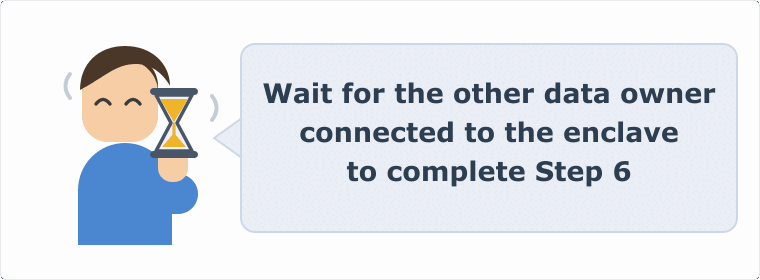


## Step 7 — View the results

The results come back to us because we submitted the job. Re-sync until the status is `done`.

In [ ]:
benchmark_owner_job = next(j for j in benchmark_owner.jobs if j.name == JOB_NAME)
print(f"  Job status   : {benchmark_owner_job.status}")

if benchmark_owner_job.status != "done" or not benchmark_owner_job.output_paths:
    print(f" 🟠 Job '{JOB_NAME}' is not finished yet — wait until the status is 'done', then re-run this cell.")
else:
    print(f" ✅ Output files : {benchmark_owner_job.output_paths}")

In [ ]:
with open(benchmark_owner_job.output_paths[0]) as f:
    result = json.load(f)

print()
print(f"  Model                   : {result['model']}")
print(f"  Total prompts evaluated : {result['total_prompts']}")
print()
for r in result["results"]:
    completion = r["completion"]
    print(f"  prompt_id  : {r['prompt_id']}")
    print(f"  prompt     : {r['prompt']}")
    print(f"  completion : {completion[:120]}..." if len(completion) > 120 else f"  completion : {completion}")
    print(f"  TTFT={r['ttft']:.2f}s  decode={r['decode_tps']:.1f} tok/s")
    print()